In [3]:
import numpy as npn
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plot 
import warnings 

warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv('insurance.csv')

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
 df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [12]:
numeric_columns = ['age','bmi','children','charges']

In [13]:
numeric_columns

['age', 'bmi', 'children', 'charges']

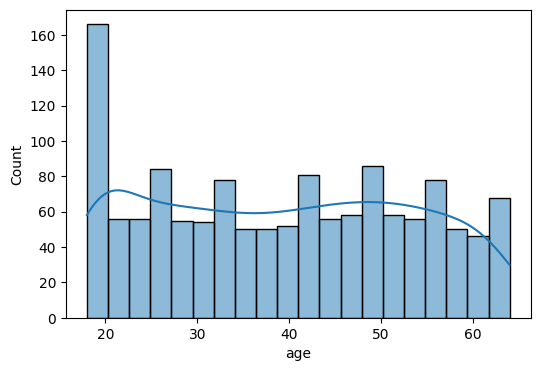

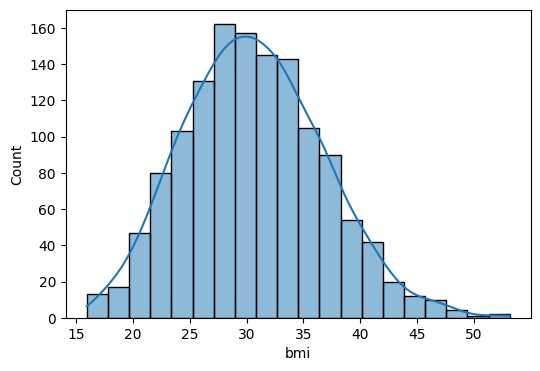

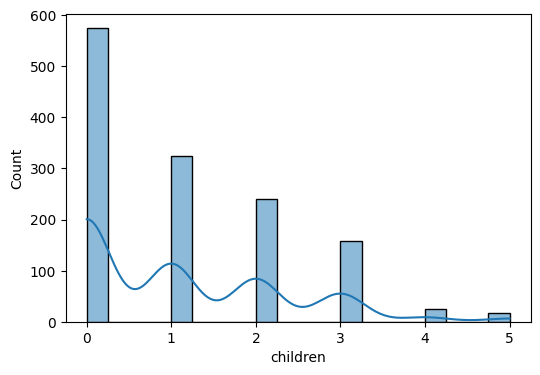

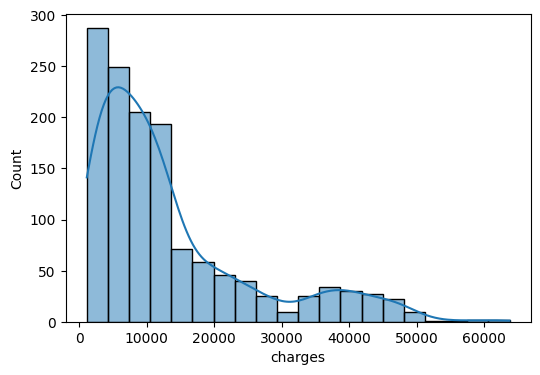

In [14]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plot.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)
    

<Axes: xlabel='children', ylabel='count'>

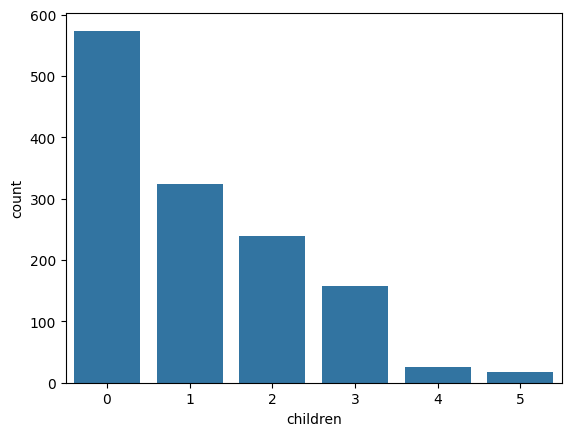

In [15]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

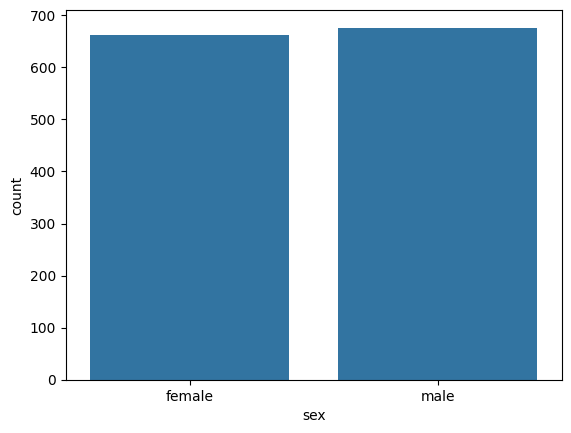

In [17]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

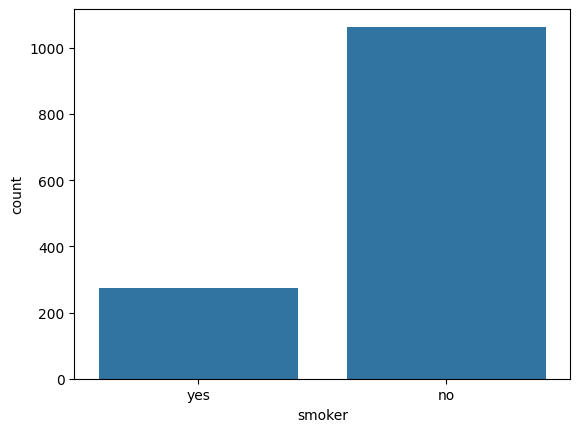

In [18]:
sns.countplot(x = df['smoker'])

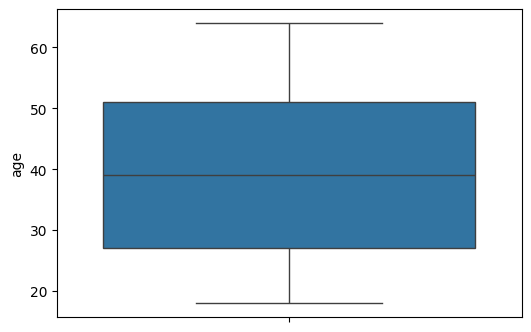

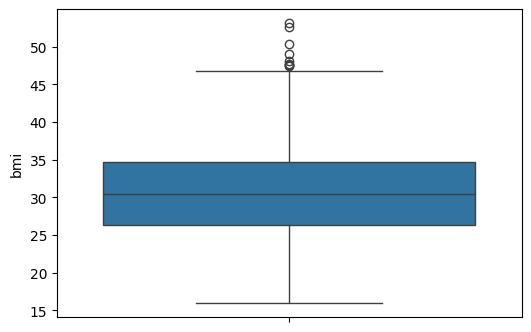

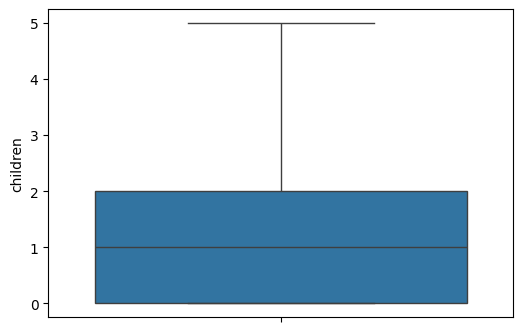

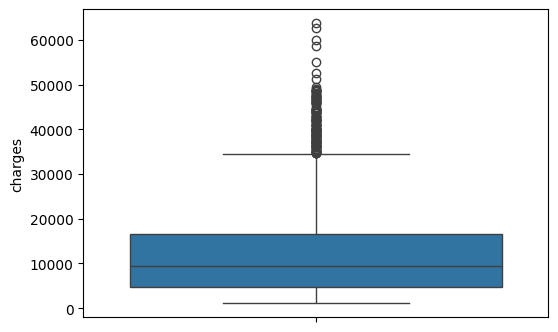

In [19]:
for col in numeric_columns:
    plot.figure (figsize=(6,4))
    sns.boxplot(df[col])

<Axes: >

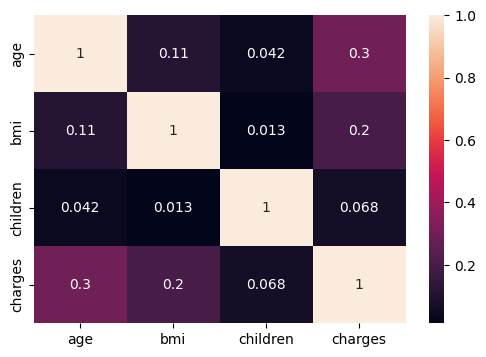

In [21]:
plot.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only = True),annot = True)

# DATA CLEANING AND PREPROCESSING

In [39]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [40]:
df_cleaned = df.copy()

In [41]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
df_cleaned = df.dropna()

In [43]:
df_cleaned.shape

(1337, 7)

In [44]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [45]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [46]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [47]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

# LABEL ENCODING

In [48]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [49]:
df_cleaned.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [50]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':0,'no':1})

In [51]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [54]:
df_cleaned.rename(columns={
    'sex':'is_male',
    'smoker':'is_smoker'
},inplace = True)

In [55]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [58]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True) 

In [59]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False


In [60]:
df_cleaned = df_cleaned.astype(int)

In [61]:
df_cleaned.head(10)

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,0,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
5,31,1,25,0,1,3756,0,1,0
6,46,1,33,1,1,8240,0,1,0
7,37,1,27,3,1,7281,1,0,0
8,37,0,29,2,1,6406,0,0,0
9,60,1,25,0,1,28923,1,0,0


# FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

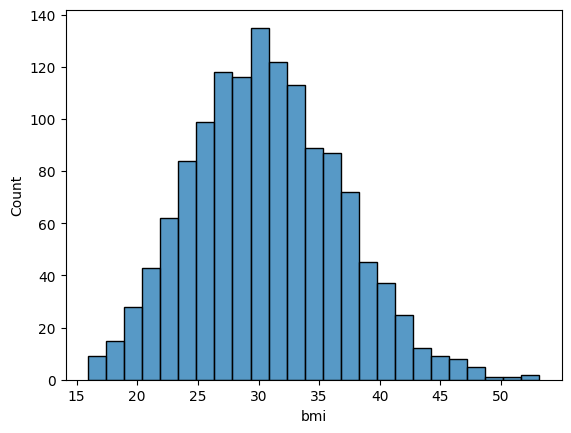

In [ ]:
sns.histplot(df['bmi'])

In [70]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9,float('inf')],
    labels = ['Underweight','Normal weight','Overweight','Obese']
)

In [71]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,0,16884,0,0,1,Overweight
1,18,0,33,1,1,1725,0,1,0,Obese
2,28,0,33,3,1,4449,0,1,0,Obese
3,33,0,22,0,1,21984,1,0,0,Normal weight
4,32,0,28,0,1,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0,Obese
1334,18,1,31,0,1,2205,0,0,0,Obese
1335,18,1,36,0,1,1629,0,1,0,Obese
1336,21,1,25,0,1,2007,0,0,1,Overweight


In [81]:
df_cleaned = df_cleaned.astype(int)

# FEATURE SCALLING


In [83]:
df_cleaned.columns

CategoricalIndex(['Normal weight', 'Overweight', 'Obese'], categories=['Underweight', 'Normal weight', 'Overweight', 'Obese'], ordered=True, dtype='category')